# CSCI E-89 Deep Learning — Assignment 03, Problem 4

**Student:** Andra Constandache  
**Tool:** OpenAI Codex  
**Reference:** “Building an Image Classifier with PyTorch” in `10_neural_nets_with_pytorch.ipynb` (Geron, 2025)

This notebook repeats the Problem 1 workflow using Codex: load Fashion-MNIST, define and train a multilayer perceptron, plot training accuracy, and make predictions. The complete scripts are embedded below in execution order and are also saved in the repository root as `load_data.py`, `model.py`, `train.py`, `plot_accuracy.py`, and `predict.py`.


## Codex session summary

The user asked to begin Problem 4 after sharing the assignment and the completed Problem 1–3 materials. I read the assignment and identified that Problem 4 repeats Problem 1 using OpenAI Codex. I reviewed the reference chapter notebook and the existing pipeline, then organized the work as five labeled, executable script cells. The pipeline uses the existing Fashion-MNIST split, a 784–300–100–10 MLP, SGD, and per-epoch training-accuracy tracking. This summary records the Codex work for this assignment; it is not a transcript of a separate chat.

## Incremental build plan

1. Load and split Fashion-MNIST; inspect one example and a mini-batch.
2. Define the classifier and verify its output shape and loss.
3. Train and save weights plus metric history.
4. Plot the training accuracy by epoch.
5. Reload the saved model and compare predictions with labels.

The repository already contains the five corresponding Python scripts. The code cells below reproduce those scripts so the notebook can be read and run as a self-contained submission. Run the notebook with the repository root as its working directory, or use the setup cell to locate that root from `WK3-codex`.


In [1]:
# Cell 1 — select the repository root, report the CUDA device, and bound CPU threads for data loading.
from pathlib import Path
import os
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "wk3-codex":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
torch.set_num_threads(min(4, os.cpu_count() or 1))
print(f"Repository working directory: {Path.cwd()}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Repository working directory: C:\Users\const\OneDrive\Desktop\CSCI E-89\WK3
PyTorch: 2.14.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## Cell 2

Load Fashion-MNIST and create reproducible training, validation, and test DataLoaders. The split is 55,000 / 5,000 / 10,000 examples.

**Captured script:** `load_data.py`.

In [2]:
# ===== Script: load_data.py =====
"""Load FashionMNIST, split it into train/valid/test, and build DataLoaders.

Follows "Building an Image Classifier with PyTorch" > "Using TorchVision to
Load the Dataset" in Geron, Hands-On Machine Learning, chapter 10.
"""

import torch
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

# Step 1: define the preprocessing pipeline.
# ToImage() turns each PIL image into a tensor-backed image of shape [1, 28, 28]
# (channels, rows, columns) with uint8 pixel values 0-255.
# ToDtype(float32, scale=True) converts to float32 and rescales pixels to [0, 1].
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

# Step 2: load FashionMNIST (downloads into ./datasets on the first run).
# The official training set has 60,000 images and the test set has 10,000.
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

# Step 3: carve a validation set out of the training set.
# Seeding first makes random_split pick the same 55,000/5,000 split every run.
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

# Step 4: wrap each dataset in a DataLoader that serves mini-batches of 32.
# Seeding again fixes the shuffle order of the training loader, so training
# runs are reproducible. Only the training set is shuffled (a new order each
# epoch); validation and test order doesn't matter.
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

if __name__ == "__main__":
    # Step 5: sanity-check the sizes of each split.
    print(f"Train: {len(train_data)}")
    print(f"Valid: {len(valid_data)}")
    print(f"Test:  {len(test_data)}")

    # Step 6: inspect one sample. Each entry is an (image, target) tuple;
    # grayscale images have a single channel, so the shape is [1, 28, 28].
    X_sample, y_sample = train_data[0]
    print(f"Sample image: {X_sample.shape}, dtype {X_sample.dtype}")
    print(f"Sample class: {train_and_valid_data.classes[y_sample]}")

    # Step 7: pull one batch to confirm the loader's output shapes:
    # images [32, 1, 28, 28] float32 and labels [32] (class ids 0-9).
    X_batch, y_batch = next(iter(train_loader))
    print(f"Batch images: {X_batch.shape}, dtype {X_batch.dtype}")
    print(f"Batch labels: {y_batch.shape}")


Train: 55000
Valid: 5000
Test:  10000
Sample image: torch.Size([1, 28, 28]), dtype torch.float32
Sample class: Ankle boot
Batch images: torch.Size([32, 1, 28, 28]), dtype torch.float32
Batch labels: torch.Size([32])


## Cell 3

Define the MLP classifier and select CUDA, Apple MPS, or CPU. A shape and initial-loss check verifies the model before training.

**Captured script:** `model.py`.

In [3]:
# ===== Script: model.py =====
"""Define the FashionMNIST image classifier (an MLP) and pick a device.

Follows "Building an Image Classifier with PyTorch" > "Building the
Classifier" in Geron, Hands-On Machine Learning, chapter 10.
"""

import torch
import torch.nn as nn

# Step 1: pick the fastest available device: an NVIDIA GPU (cuda), an Apple
# GPU (mps), or the CPU as a fallback.
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"


# Step 2: define the classifier as a multilayer perceptron.
# Flatten turns each [1, 28, 28] image into a 784-value vector, two hidden
# layers with ReLU activations learn features, and the output layer produces
# one raw score (logit) per class. No softmax here: CrossEntropyLoss applies
# it internally, which is more numerically stable.
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)


if __name__ == "__main__":
    from load_data import train_loader

    # Step 3: build the model with Geron's sizes (784 -> 300 -> 100 -> 10) and
    # move it to the device. Seeding makes the initial weights reproducible.
    torch.manual_seed(42)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                            n_classes=10).to(device)

    # Step 4: the loss for multiclass classification with integer labels.
    xentropy = nn.CrossEntropyLoss()

    # Step 5: sanity-check the architecture and parameter count
    # (784*300+300 + 300*100+100 + 100*10+10 = 266,610).
    print(f"Device: {device}")
    print(model)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {n_params:,}")

    # Step 6: run one batch through the untrained model to confirm the output
    # shape is [32, 10] (one logit per class) and the loss is about
    # ln(10) = 2.30, what random guessing over 10 classes gives.
    X_batch, y_batch = next(iter(train_loader))
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    with torch.no_grad():
        logits = model(X_batch)
    print(f"Logits shape: {logits.shape}")
    print(f"Initial loss: {xentropy(logits, y_batch).item():.4f}")


Device: cuda
ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Trainable parameters: 266,610
Logits shape: torch.Size([32, 10])
Initial loss: 2.3156


## Cell 4

Train for 20 epochs with SGD, record training and validation accuracy, and save the model weights and metric history.

**Captured script:** `train.py`.

In [4]:
# ===== Script: train.py =====
"""Train the FashionMNIST ImageClassifier and record its learning history.

Follows "Building an Image Classifier with PyTorch" in Geron, Hands-On Machine
Learning, chapter 10, reusing the chapter's evaluate_tm() and train2().
"""

import json

import torch
import torch.nn as nn
import torchmetrics

from load_data import train_loader, valid_loader
from model import ImageClassifier, device


# Step 1: evaluation helper. Runs the model over a whole DataLoader and returns
# one metric value for the full dataset (not an average of per-batch values).
def evaluate_tm(model, data_loader, metric):
    model.eval()     # evaluation mode (matters for dropout/batch norm layers)
    metric.reset()   # clear any state left over from a previous call
    with torch.no_grad():  # no gradients needed, saves memory and time
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # accumulate counts batch by batch
    return metric.compute()  # final metric over every sample seen


# Step 2: training loop. For each epoch it runs mini-batch gradient descent
# over the training set, then measures accuracy on the validation set.
# Returns a history dict of per-epoch training loss, training metric and
# validation metric, which is what the learning curves are plotted from.
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            # evaluate_tm() switches to eval mode, so switch back every batch
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)             # forward pass: logits
            loss = criterion(y_pred, y_batch)   # compare with true labels
            total_loss += loss.item()
            loss.backward()                     # backprop: compute gradients
            optimizer.step()                    # update the weights
            optimizer.zero_grad()               # reset gradients for next batch
            metric.update(y_pred, y_batch)      # running training accuracy
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


if __name__ == "__main__":
    n_epochs = 20

    # Step 3: build the model and loss exactly as in model.py. Seeding makes
    # the initial weights, and so the whole run, reproducible.
    torch.manual_seed(42)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                            n_classes=10).to(device)
    xentropy = nn.CrossEntropyLoss()

    # Step 4: plain stochastic gradient descent with learning rate 0.1, and
    # multiclass accuracy (fraction of images whose top logit is the true class)
    # as the metric to track.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

    # Step 5: train for 20 epochs.
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                     valid_loader, n_epochs)

    # Step 6: save the trained weights and the history so later scripts can
    # evaluate the model and plot the learning curves without retraining.
    torch.save(model.state_dict(), "fashion_mnist_mlp.pt")
    with open("history.json", "w") as f:
        json.dump(history, f, indent=2)
    print("Saved fashion_mnist_mlp.pt and history.json")


Epoch 1/20, train loss: 0.6059, train metric: 0.7810, valid metric: 0.8426
Epoch 2/20, train loss: 0.4057, train metric: 0.8501, valid metric: 0.8392
Epoch 3/20, train loss: 0.3629, train metric: 0.8659, valid metric: 0.8556
Epoch 4/20, train loss: 0.3352, train metric: 0.8770, valid metric: 0.8642
Epoch 5/20, train loss: 0.3144, train metric: 0.8843, valid metric: 0.8774
Epoch 6/20, train loss: 0.2996, train metric: 0.8870, valid metric: 0.8626
Epoch 7/20, train loss: 0.2852, train metric: 0.8921, valid metric: 0.8774
Epoch 8/20, train loss: 0.2749, train metric: 0.8966, valid metric: 0.8746
Epoch 9/20, train loss: 0.2641, train metric: 0.9009, valid metric: 0.8810
Epoch 10/20, train loss: 0.2540, train metric: 0.9027, valid metric: 0.8766
Epoch 11/20, train loss: 0.2463, train metric: 0.9065, valid metric: 0.8848
Epoch 12/20, train loss: 0.2367, train metric: 0.9099, valid metric: 0.8868
Epoch 13/20, train loss: 0.2294, train metric: 0.9123, valid metric: 0.8866
Epoch 14/20, train lo

## Cell 5

Plot and save training accuracy for each epoch using the history written by the training script.

**Captured script:** `plot_accuracy.py`.

Saved training_accuracy.png


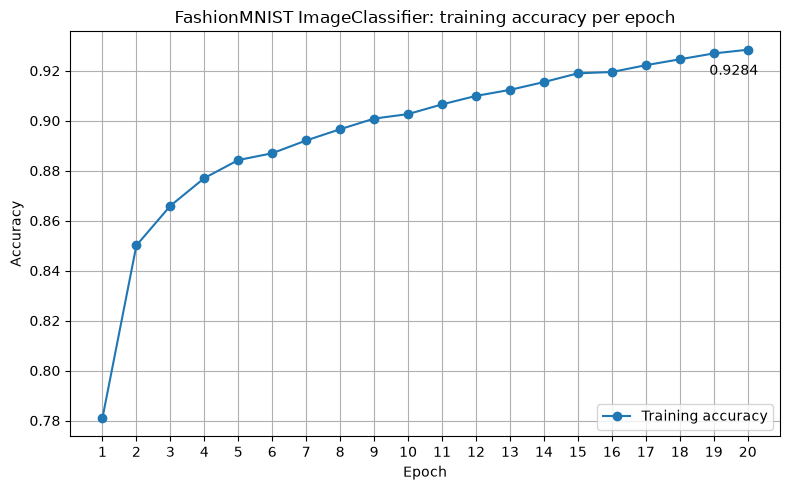

In [5]:
# ===== Script: plot_accuracy.py =====
"""Plot the training accuracy per epoch of the FashionMNIST ImageClassifier.

Reads history.json, which train.py writes after training, so the model does
not need to be retrained to draw the plot.
"""

import json

import matplotlib.pyplot as plt
import numpy as np

# Step 1: load the per-epoch history saved by train.py. It holds three lists
# with one value per epoch: train_losses, train_metrics and valid_metrics.
with open("history.json") as f:
    history = json.load(f)

# Step 2: pull out the training accuracy and number the epochs from 1, not 0.
train_acc = np.array(history["train_metrics"])
epochs = np.arange(1, len(train_acc) + 1)

# Step 3: draw the curve, one marker per epoch.
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, "o-", label="Training accuracy")

# Step 4: label the final value so the end point can be read off directly.
plt.annotate(f"{train_acc[-1]:.4f}", xy=(epochs[-1], train_acc[-1]),
             xytext=(-10, -18), textcoords="offset points", ha="center")

# Step 5: axes, title and grid. Integer ticks, since epochs are whole numbers.
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FashionMNIST ImageClassifier: training accuracy per epoch")
plt.xticks(epochs)
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()

# Step 6: save the figure as a PNG (for the report) and show it on screen.
plt.savefig("training_accuracy.png", dpi=150)
print("Saved training_accuracy.png")
plt.show()


## Cell 6

Reload the trained model, classify three validation images, and display predicted and true labels.

**Captured script:** `predict.py`.

Predicted class indices: [7, 4, 2]
Predicted class names:   ['Sneaker', 'Coat', 'Pullover']
True class names:        ['Sneaker', 'Coat', 'Pullover']

Image 1: predicted Sneaker (85.9% confidence), true Sneaker -> correct
Image 2: predicted Coat (99.6% confidence), true Coat -> correct
Image 3: predicted Pullover (80.9% confidence), true Pullover -> correct


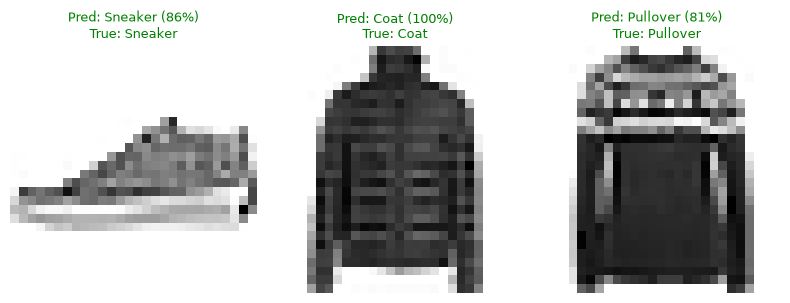

In [6]:
# ===== Script: predict.py =====
"""Use the trained ImageClassifier to predict the class of 3 validation images.

Follows the prediction step of "Building an Image Classifier with PyTorch" in
Geron, Hands-On Machine Learning, chapter 10. Loads the weights saved by
train.py, so run that first.
"""

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from load_data import train_and_valid_data, valid_loader
from model import ImageClassifier, device

# Step 1: rebuild the same architecture and load the trained weights into it.
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
model.load_state_dict(torch.load("fashion_mnist_mlp.pt", map_location=device))

# Step 2: switch to evaluation mode for inference.
model.eval()

# Step 3: take the first 3 images of the first validation batch. The
# validation loader is not shuffled, so these are the same 3 images every run.
X_new, y_new = next(iter(valid_loader))
X_new, y_new = X_new[:3].to(device), y_new[:3]

# Step 4: run the model without tracking gradients. The output is one logit
# (raw score) per class for each image.
with torch.no_grad():
    y_pred_logits = model(X_new)

# Step 5: the predicted class is the index of the largest logit. Softmax turns
# the logits into probabilities, giving the model's confidence in that class.
y_pred = y_pred_logits.argmax(dim=1)
y_proba = F.softmax(y_pred_logits, dim=1).cpu()

# Step 6: map class indices to names (e.g. 0 -> "T-shirt/top") and compare
# each prediction with the true label.
class_names = train_and_valid_data.classes
print("Predicted class indices:", y_pred.tolist())
print("Predicted class names:  ", [class_names[i] for i in y_pred])
print("True class names:       ", [class_names[i] for i in y_new])
print()
for i, (pred, true) in enumerate(zip(y_pred.tolist(), y_new.tolist())):
    verdict = "correct" if pred == true else "WRONG"
    print(f"Image {i + 1}: predicted {class_names[pred]} "
          f"({y_proba[i, pred]:.1%} confidence), "
          f"true {class_names[true]} -> {verdict}")

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for i, ax in enumerate(axes):
    pred, true = y_pred[i].item(), y_new[i].item()
    ax.imshow(X_new[i].cpu().squeeze(), cmap="binary")
    ax.set_title(f"Pred: {class_names[pred]} ({y_proba[i, pred]:.0%})\n"
                 f"True: {class_names[true]}",
                 color="green" if pred == true else "red", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Results and files

The training cell writes `fashion_mnist_mlp.pt` and `history.json` in the repository root. The plotting cell writes `training_accuracy.png`. The prediction cell reports the predicted and true class names and displays three validation examples. These generated outputs can be recreated by running the cells in order.
